# Experto 2 — proyección del PSA

Este experto no clasifica: **regresa**. Dada la serie de PSA de un paciente y su
contexto clínico, entrega el valor esperado a un horizonte, su intervalo, y si la
tendencia sube o baja.

Su papel en la deliberación es distinto al de los clasificadores: aporta una
magnitud física con su error, que el resto de expertos y el deliberador pueden
usar como evidencia adicional.

In [1]:
import sys, json, math, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(ROOT))
DATA = ROOT.parent / "data_filtered" / "task1"
ART  = ROOT / "task_one" / "train" / "artifacts"

from chimera_experts.io import load_cases
from chimera_experts.features_psa import series, fit_trajectory
from chimera_experts.psa_projector import PSAProjectorExpert

proj  = PSAProjectorExpert.load(ROOT / "task_one" / "expert_two" / "model" / "expert_two_psa_projector.joblib")
cases = load_cases(DATA, task=1)
print(f"regresor elegido: {proj.champion}")
print(f"entrenado con {proj.meta['n_examples']} prefijos de {proj.meta['n_patients']} pacientes")
print(f"variables: {len(proj.feature_names)}")

regresor elegido: extra_trees_anchored
entrenado con 373 prefijos de 195 pacientes
variables: 23


## 1. Qué se compara, y contra qué

Los dos primeros son los suelos que hay que batir para que el aprendizaje se
justifique: repetir el último valor, y extrapolar la recta ajustada a `log(PSA)`.

Fíjate en `loglinear_extrapolation`: su R² es **negativo**, es decir, extrapolar
linealmente una serie corta y ruidosa de PSA es peor que no hacer nada. Ese es
justamente el hueco que llena el regresor.

,model,mae_log,rmse_log,median_relative_error,r2_log,oof_sd_across_repeats,mae_log_psa_gt50,bias_log_psa_gt50
0,extra_trees_anchored,0.315,0.551,0.161,0.600,0.066,1.660,1.660
1,extra_trees,0.321,0.560,0.156,0.587,0.063,1.690,1.690
2,random_forest,0.332,0.580,0.158,0.557,0.076,1.774,1.774
3,random_forest_anchored,0.334,0.574,0.178,0.566,0.069,1.912,1.912
4,grad_boosting,0.351,0.587,0.211,0.546,0.126,1.912,1.912
5,grad_boosting_anchored,0.353,0.588,0.209,0.545,0.117,1.854,1.854
6,huber_anchored,0.357,0.593,0.195,0.536,0.055,1.843,1.843
7,huber,0.357,0.593,0.194,0.536,0.055,1.843,1.843
8,ridge_anchored,0.377,0.597,0.249,0.530,0.076,1.925,1.925
9,ridge,0.378,0.599,0.252,0.528,0.077,1.952,1.952


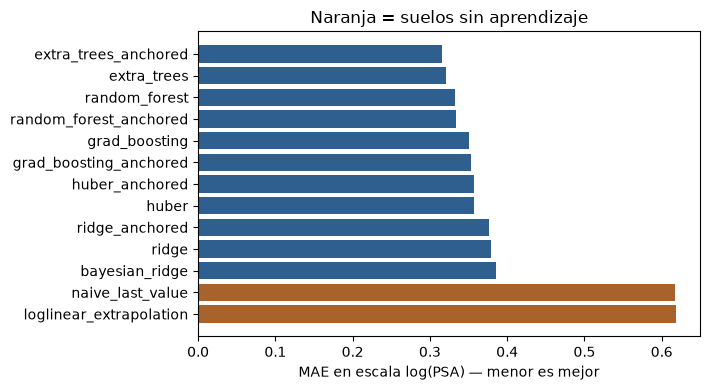

In [2]:
bk = pd.read_csv(ART / "psa_projector_bakeoff.csv")
display(bk.round(3))

fig, ax = plt.subplots(figsize=(7.2, 4))
b = bk.sort_values("mae_log")
colors = ["#a8632c" if n in ("naive_last_value", "loglinear_extrapolation") else "#2f5f8f" for n in b["model"]]
ax.barh(b["model"][::-1], b["mae_log"][::-1], color=colors[::-1])
ax.set_xlabel("MAE en escala log(PSA) — menor es mejor")
ax.set_title("Naranja = suelos sin aprendizaje")
plt.tight_layout(); plt.show()

## 2. El intervalo cubre lo que promete

La predicción conforme *jackknife+* garantiza cobertura en muestra finita sin
suponer normalidad. Todos los métodos cubren el 95 % —eso lo garantiza la
construcción—, así que lo que distingue a un buen regresor es la **anchura**: a
igual cobertura, el mejor es el que da la banda más estrecha.

,model,interval,empirical_coverage,median_width_log,median_width_ratio
0,extra_trees_anchored,jackknife_plus_95,0.952,2.497,3.486
1,extra_trees,jackknife_plus_95,0.952,2.591,3.652
2,random_forest,jackknife_plus_95,0.952,2.797,4.049
3,random_forest_anchored,jackknife_plus_95,0.952,2.588,3.647
4,grad_boosting,jackknife_plus_95,0.952,2.853,4.164
5,grad_boosting_anchored,jackknife_plus_95,0.952,2.706,3.868
6,huber_anchored,jackknife_plus_95,0.952,2.809,4.074
7,huber,jackknife_plus_95,0.952,2.809,4.074
8,ridge_anchored,jackknife_plus_95,0.952,2.786,4.028
9,ridge,jackknife_plus_95,0.952,2.838,4.134


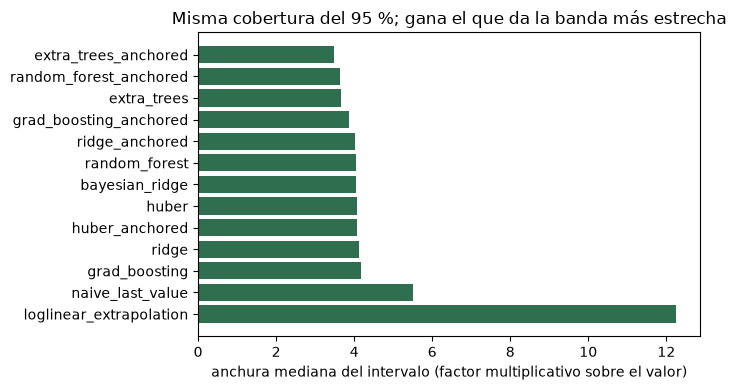

In [3]:
cov = pd.read_csv(ART / "psa_projector_coverage.csv")
display(cov.round(3))

fig, ax = plt.subplots(figsize=(7.2, 4))
c = cov.sort_values("median_width_ratio")
ax.barh(c["model"][::-1], c["median_width_ratio"][::-1], color="#2f6f4f")
ax.set_xlabel("anchura mediana del intervalo (factor multiplicativo sobre el valor)")
ax.set_title("Misma cobertura del 95 %; gana el que da la banda más estrecha")
plt.tight_layout(); plt.show()

## 3. Trayectorias y proyección, caso a caso

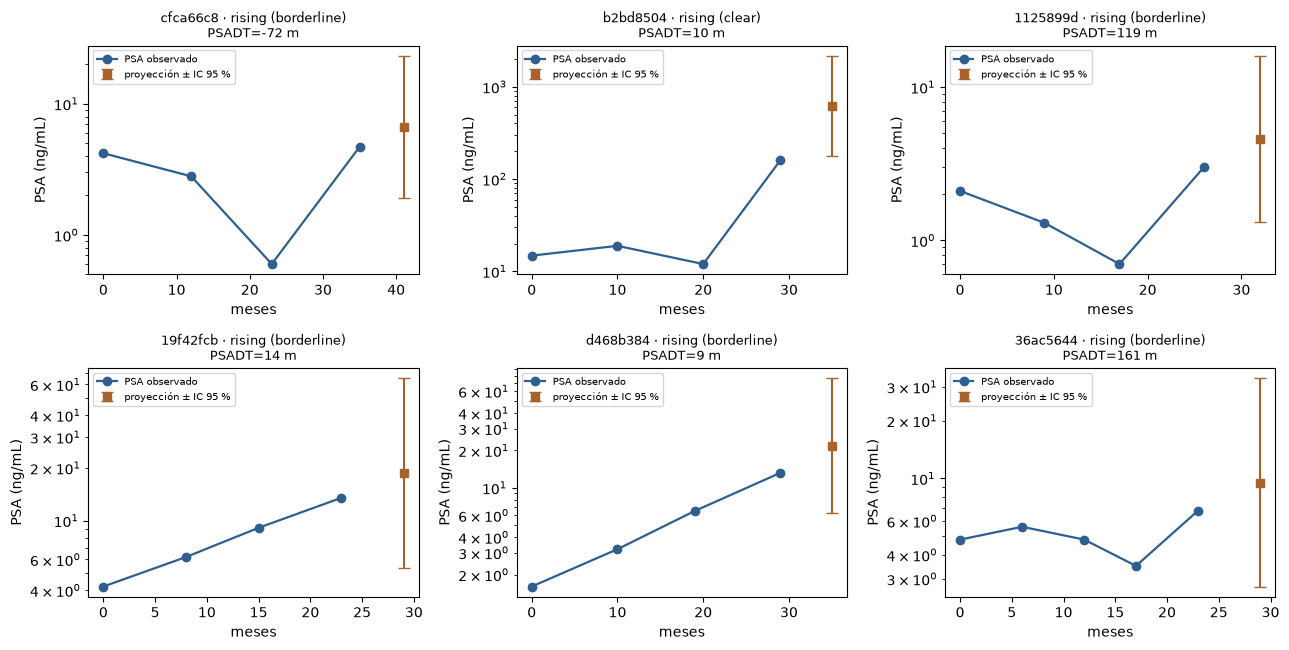

In [4]:
def plot_case(c, ax, horizon=6.0):
    s = series(c.clinical)
    if not s: return
    t0 = s[0][0]
    t = [p[0] - t0 for p in s]; v = [p[1] for p in s]
    p = proj.project(c, horizon)
    ax.plot(t, v, "o-", c="#2f5f8f", lw=1.6, label="PSA observado")
    tp = t[-1] + horizon
    ax.errorbar([tp], [p.psa_projected],
                yerr=[[max(p.psa_projected - p.ci_lo, 0)], [max(p.ci_hi - p.psa_projected, 0)]],
                fmt="s", c="#a8632c", capsize=4, label="proyección ± IC 95 %")
    ax.set_yscale("log"); ax.set_xlabel("meses"); ax.set_ylabel("PSA (ng/mL)")
    ax.set_title(f"{c.case_id[-8:]} · {p.direction} ({p.direction_confidence})\n"
                 f"PSADT={p.doubling_time_months:.0f} m", fontsize=9)
    ax.legend(fontsize=7)

sel = [c for c in cases if len(series(c.clinical)) >= 4][:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.6))
for c, ax in zip(sel, axes.ravel()):
    plot_case(c, ax)
plt.tight_layout(); plt.show()

## 4. Cómo se reparte la tendencia en toda la cohorte

El experto declara `rising`/`falling` sólo cuando la banda conforme entera cae a
un lado del último valor. Es deliberadamente conservador: prefiere decir
`indeterminate` a firmar una tendencia que sus datos no sostienen.

confianza,borderline,clear,uncertain,All
direccion,,,,
indeterminate,0,0,31,31
rising,154,10,0,164
All,154,10,31,195


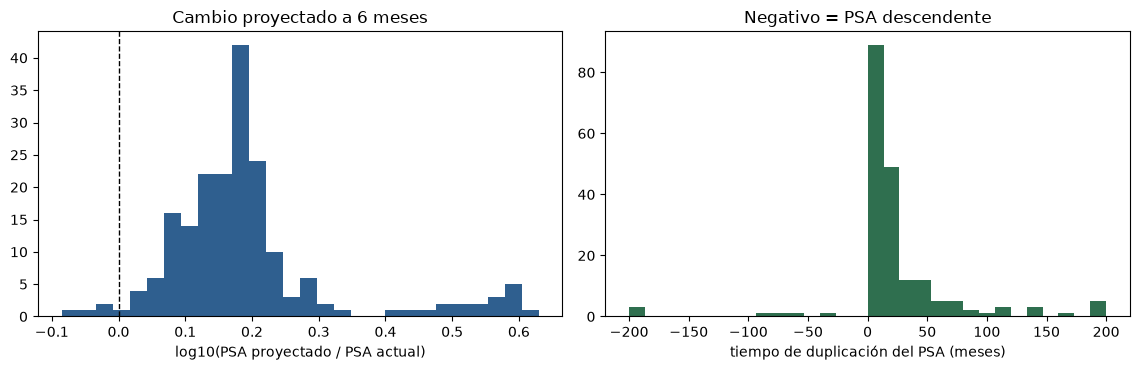

,case_id,psa_last,psa_proj,ci_lo,ci_hi,direccion,confianza,n_puntos,PSADT_meses,r2_log
0,PT-pseudo_0020cfca66c8,4.7,6.649991,1.907889,23.178690,rising,borderline,4,-71.722340,0.023191
1,PT-pseudo_0169468160c6,187.0,632.889672,181.576719,2205.950956,rising,borderline,3,3.504991,0.390877
2,PT-pseudo_01b643727538,9.3,12.096539,3.470510,42.162754,rising,borderline,3,20.397234,0.214190
3,PT-pseudo_033f1a8e1503,5.9,7.949928,2.280843,27.709649,rising,borderline,3,68.883817,0.356607
4,PT-pseudo_0615b2bd8504,160.0,618.263025,177.380318,2154.969455,rising,clear,4,10.306279,0.493775
5,PT-pseudo_062a1125899d,3.0,4.580686,1.314204,15.966083,rising,borderline,4,118.699614,0.010592
6,PT-pseudo_06b319f42fcb,13.5,18.626811,5.344052,64.924163,rising,borderline,4,13.562139,0.999504
7,PT-pseudo_075dd468b384,13.2,21.810284,6.257394,76.020227,rising,borderline,4,9.457502,0.999445
8,PT-pseudo_079636ac5644,6.8,9.524414,2.732564,33.197555,rising,borderline,5,160.796100,0.025404
9,PT-pseudo_0930885168c9,8.7,14.094682,4.043779,49.127324,rising,borderline,3,6.886642,0.999923


In [5]:
rows = []
for c in cases:
    p = proj.project(c, 6.0)
    rows.append({"case_id": c.case_id, "psa_last": p.psa_last, "psa_proj": p.psa_projected,
                 "ci_lo": p.ci_lo, "ci_hi": p.ci_hi, "direccion": p.direction,
                 "confianza": p.direction_confidence, "n_puntos": p.n_points,
                 "PSADT_meses": p.doubling_time_months, "r2_log": p.fit_r2_log})
pr = pd.DataFrame(rows)
display(pd.crosstab(pr["direccion"], pr["confianza"], margins=True))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].hist(np.log10(pr["psa_proj"] / pr["psa_last"]).replace([np.inf, -np.inf], np.nan).dropna(),
             bins=28, color="#2f5f8f")
axes[0].axvline(0, c="k", lw=1, ls="--"); axes[0].set_xlabel("log10(PSA proyectado / PSA actual)")
axes[0].set_title("Cambio proyectado a 6 meses")
dt = pr["PSADT_meses"].replace([np.inf, -np.inf], np.nan).dropna()
axes[1].hist(dt.clip(-200, 200), bins=30, color="#2f6f4f")
axes[1].set_xlabel("tiempo de duplicación del PSA (meses)")
axes[1].set_title("Negativo = PSA descendente")
plt.tight_layout(); plt.show()
pr.head(10)

## 5. Un aviso sobre estos datos

La serie `psa_trend` de este corpus es sólo **parcialmente coherente** con el PSA
del caso: `psap` (el PSA previo del prompt estructurado) coincide con el
penúltimo punto de la serie en apenas 8 de 195 casos, y predice `log(psa)` con
R² = 0.944, mientras que el penúltimo punto de la serie sólo llega a R² = 0.507.

Es decir: el proyector se valida contra la más ruidosa de las dos historias
disponibles. Eso hace que su intervalo sea **conservador**, que es el sentido
correcto del error, pero conviene saberlo antes de leer la anchura de la banda
como si fuera fisiología.

In [6]:
from chimera_experts.features_psa import series as S
rows = []
for c in cases:
    s = S(c.clinical); p = c.prompt
    if len(s) > 1:
        rows.append({"psa": p["psa"], "psap": p["psap"], "penultimo_trend": s[-2][1],
                     "ultimo_trend": s[-1][1]})
d = pd.DataFrame(rows)
print(f"psa == último punto de la serie : {(abs(d['psa']-d['ultimo_trend'])<1e-6).mean():.1%}")
print(f"psap == penúltimo punto         : {(abs(d['psap']-d['penultimo_trend'])<1e-6).mean():.1%}")
print(f"R² de log(psa) sobre log(psap)            : {np.corrcoef(np.log(d['psa']), np.log(d['psap']))[0,1]**2:.3f}")
print(f"R² de log(psa) sobre log(penúltimo trend) : {np.corrcoef(np.log(d['psa']), np.log(d['penultimo_trend']))[0,1]**2:.3f}")

psa == último punto de la serie : 99.5%
psap == penúltimo punto         : 4.1%
R² de log(psa) sobre log(psap)            : 0.944
R² de log(psa) sobre log(penúltimo trend) : 0.507


## 6. Salida del experto para el deliberador

In [7]:
p = proj.project(cases[1], horizon_months=6.0)
print(json.dumps(p.to_dict(), indent=2, ensure_ascii=False))
print("\nvariables que este experto entrega al Experto 3 (bloque G):")
print(json.dumps(proj.features_for_fusion(cases[1]), indent=2, ensure_ascii=False))

{
  "horizon_months": 6.0,
  "psa_last": 187.0,
  "psa_projected": 632.8896716561804,
  "ci_lo": 181.57671883398638,
  "ci_hi": 2205.9509559443345,
  "log_sigma": 0.6370499259569719,
  "direction": "rising",
  "direction_confidence": "borderline",
  "doubling_time_months": 3.5049906432553684,
  "velocity_ng_ml_year": 156.29763779527556,
  "n_points": 3,
  "span_months": 13.0,
  "fit_r2_log": 0.39087722270400616,
  "method": "extra_trees_anchored"
}

variables que este experto entrega al Experto 3 (bloque G):
{
  "e2_log_projected_psa": 6.450296112571124,
  "e2_log_change_vs_last": 1.219187495716537,
  "e2_projected_over_last": 3.3844367468244942,
  "e2_interval_width_log": 2.4972357097513296,
  "e2_direction_rising": 1.0,
  "e2_direction_is_clear": 0.0,
  "e2_fit_r2_log": 0.39087722270400616
}
